In [10]:
!pip install umap-learn pillow numpy matplotlib scikit-learn tqdm


In [11]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import umap
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm
import time

In [12]:
# Load and preprocess image
def load_and_display_image(image_path, max_pixels=10000):
    """Load image and show pixel information"""
    print("Loading image...")
    img = Image.open(image_path)
    img = img.convert('RGB')
    
    # Original dimensions
    width, height = img.size
    print(f"Original dimensions: {width}x{height} ({width*height} pixels)")
    
    # Downsample if needed
    if width * height > max_pixels:
        scale = np.sqrt(max_pixels / (width * height))
        new_width = int(width * scale)
        new_height = int(height * scale)
        img = img.resize((new_width, new_height))
        print(f"Resized to: {new_width}x{new_height} ({new_width*new_height} pixels)")
    
    pixels = np.array(img)
    pixels_2d = pixels.reshape(-1, 3)
    
    # Display first few pixels
    print("\nFirst 5 pixels (RGB values):")
    print(pixels_2d[:5])
    
    return pixels_2d, img.size


In [13]:
# Generate UMAP embedding
def create_umap_with_progress(pixels, n_neighbors=15, min_dist=0.1, random_state=42):
    """Create UMAP embedding with progress updates"""
    print("\nProcessing steps:")
    
    # 1. Scaling
    print("1/3 Scaling RGB values...")
    scaler = StandardScaler()
    scaled_pixels = scaler.fit_transform(pixels)
    print("   Scaling complete")
    
    # 2. UMAP
    print("2/3 Creating UMAP reducer...")
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state,
        verbose=True  # This will show internal progress
    )
    
    # 3. Fitting
    print("3/3 Fitting UMAP (this may take a while)...")
    start_time = time.time()
    embedding = reducer.fit_transform(scaled_pixels)
    end_time = time.time()
    
    print(f"\nUMAP processing completed in {end_time - start_time:.2f} seconds")
    
    # Display first few embeddings
    print("\nFirst 5 embeddings (2D coordinates):")
    print(embedding[:5])
    
    return embedding

In [14]:
# Visualize UMAP results
def plot_results(embedding, pixels):
    """Plot UMAP results with color information"""
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=pixels/255,
        s=2,
        alpha=0.6
    )
    plt.title("UMAP projection of image colors")
    plt.colorbar(scatter)
    plt.show()

In [15]:
# Optional: Add clustering to find dominant color groups
def cluster_colors(embedding, n_clusters=5):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(embedding)
    return clusters

Loading image...
Original dimensions: 300x200 (60000 pixels)
Resized to: 122x81 (9882 pixels)

First 5 pixels (RGB values):
[[123  29   1]
 [ 46   6   0]
 [ 55   2   1]
 [102  18   1]
 [ 84  25   1]]

Processing steps:
1/3 Scaling RGB values...
   Scaling complete
2/3 Creating UMAP reducer...
3/3 Fitting UMAP (this may take a while)...
UMAP(n_jobs=1, random_state=42, verbose=True)
Thu Feb 13 18:53:11 2025 Construct fuzzy simplicial set
Thu Feb 13 18:53:11 2025 Finding Nearest Neighbors
Thu Feb 13 18:53:11 2025 Building RP forest with 10 trees
Thu Feb 13 18:53:11 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Thu Feb 13 18:53:11 2025 Finished Nearest Neighbor Search
Thu Feb 13 18:53:11 2025 Construct embedding


/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

Epochs completed:   4%| ▍          21/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  13%| █▎         63/500 [00:01]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  93%| █████████▎ 465/500 [00:08]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:09]


Thu Feb 13 18:53:21 2025 Finished embedding

UMAP processing completed in 10.20 seconds

First 5 embeddings (2D coordinates):
[[11.468872   7.811652 ]
 [ 3.3731008 -4.4814825]
 [23.996037   4.119276 ]
 [12.377318   4.0813293]
 [10.556187   4.8793035]]


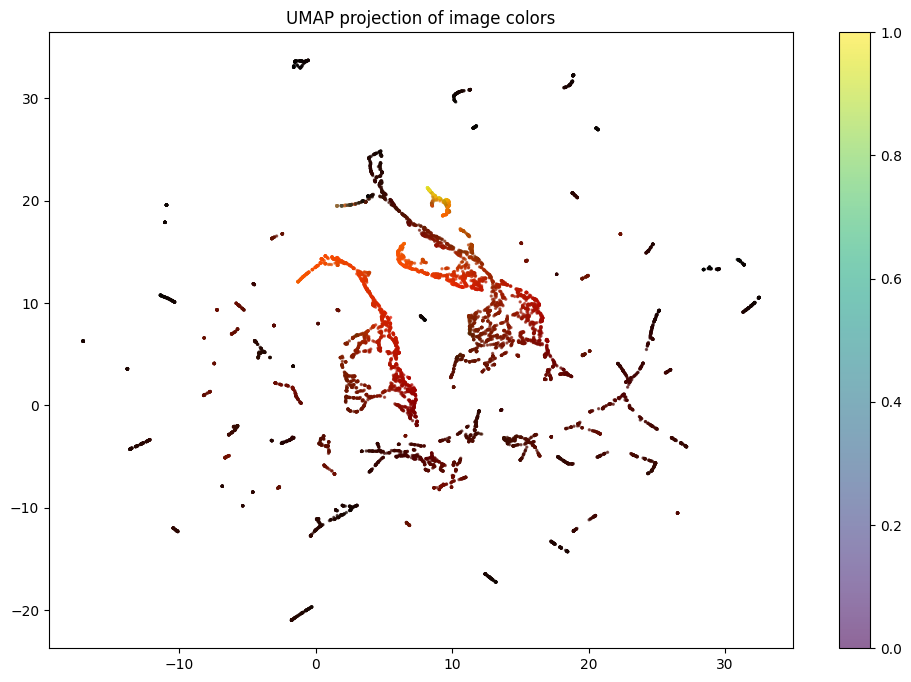


Embeddings saved to 'umap_embeddings.npy'


In [16]:
# Example usage:
image_path = "test3.jpg"  # Replace with your image path

# 1. Load and preprocess
pixels, size = load_and_display_image(image_path)

# 2. Create UMAP embedding
embedding = create_umap_with_progress(pixels)

# 3. Visualize
plot_results(embedding, pixels)

# Optional: Save the embeddings
np.save('umap_embeddings.npy', embedding)
print("\nEmbeddings saved to 'umap_embeddings.npy'")